In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import (Input, Dense, Dropout, Reshape, Conv1D, Flatten, 
                                     concatenate, BatchNormalization, LeakyReLU)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

2025-04-22 15:38:56.176009: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745336336.428745      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745336336.499688      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/us-accidents/US_Accidents_March23.csv')
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [3]:
df = df.dropna(subset=['Temperature(F)', 'Humidity(%)', 'Wind_Speed(mph)', 
                       'Visibility(mi)', 'Pressure(in)', 'State', 'Weather_Condition', 'Severity'])

# Encode categorical features
df['State'] = pd.Categorical(df['State']).codes
df['Weather_Condition'] = pd.Categorical(df['Weather_Condition']).codes

# Features and labels
features = ['Temperature(F)', 'Humidity(%)', 'Wind_Speed(mph)', 
            'Visibility(mi)', 'Pressure(in)', 'State', 'Weather_Condition']

In [4]:
X = df[features]
y = df['Severity'].values
y = y - 1

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [6]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

In [7]:
BATCH_SIZE = 256
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1745336448.516439      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745336448.517191      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, Add, concatenate
from tensorflow.keras.models import Model

def transformer_block(x, num_heads=4, ff_dim=64, dropout_rate=0.1):
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=x.shape[-1])(x, x)
    attn_output = Dropout(dropout_rate)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(Add()([x, attn_output]))

    ffn_output = Dense(ff_dim, activation='relu')(out1)
    ffn_output = Dropout(dropout_rate)(ffn_output)
    out2 = LayerNormalization(epsilon=1e-6)(Add()([out1, ffn_output]))
    return out2

input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,), name='Input')

# Transformer Path (requires reshaping input to sequence)
reshaped = tf.keras.layers.Reshape((input_dim, 1))(input_layer)
transformed = transformer_block(reshaped, num_heads=2, ff_dim=64)
transformed = tf.keras.layers.Flatten()(transformed)

# MLP Path
mlp = Dense(128, activation='relu')(input_layer)
mlp = Dropout(0.3)(mlp)
mlp = Dense(64, activation='relu')(mlp)

# Merge
merged = concatenate([transformed, mlp])
merged = Dense(64, activation='relu')(merged)
merged = Dropout(0.3)(merged)

# Output Layer
output = Dense(4, activation='softmax')(merged)

# Model Compile
model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)        │ (None, 7)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 7, 1)           │              0 │ Input[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 7, 1)           │             15 │ reshape[0][0],         │
│ (MultiHeadAttention)      │                        │                │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 7, 1)           │              0 │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 7, 1)           │              0 │ reshape[0][0],         │
│                           │                        │                │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 7, 1)           │              2 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 7, 64)          │            128 │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 7, 64)          │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 7, 64)          │              0 │ layer_normalization[0… │
│                           │                        │                │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 128)            │          1,024 │ Input[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 7, 64)          │            128 │ add_1[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 128)            │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 448)            │              0 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 64)             │          8,256 │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 512)            │              0 │ flatten[0][0],         │
│                           │                        │                │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 64)             │         32,832 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)  

 Total params: 42,645 (166.58 KB)

 Trainable params: 42,645 (166.58 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


In [11]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

# Safe datetime conversion for nanosecond strings
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce', format='mixed')

# Drop rows with parsing failures
df = df.dropna(subset=['Start_Time'])

# Extract hour and weekday from Start_Time
df['Hour'] = df['Start_Time'].dt.hour
df['Weekday'] = df['Start_Time'].dt.weekday
df.drop('Start_Time', axis=1, inplace=True)

# Separate features
cat_cols = ['State', 'City', 'Weather_Condition']
seq_cols = ['Hour', 'Weekday']
num_cols = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)']
target_col = 'Severity'

# Encode categorical features
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # ensure no NaNs or weird values
    label_encoders[col] = le

# Normalize numerical features
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [12]:
X_cat = df[cat_cols].values.astype(np.int64)
X_num = df[num_cols].values.astype(np.float32)
X_seq = df[seq_cols].values.reshape(-1, len(seq_cols), 1)
y = df[target_col].values.astype(np.int64) - 1  # Make severity start from 0

# Train-test split
X_cat_train, X_cat_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_cat, X_num, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_cat_train = torch.tensor(X_cat_train)
X_cat_test = torch.tensor(X_cat_test)
X_num_train = torch.tensor(X_num_train)
X_num_test = torch.tensor(X_num_test)
y_train = torch.tensor(y_train)
y_test = torch.tensor(y_test)

In [13]:
X_cat_train, X_cat_test, X_num_train, X_num_test, X_seq_train, X_seq_test, y_train, y_test = train_test_split(
    X_cat, X_num, X_seq, y, test_size=0.2, random_state=42
)

In [14]:
class AccidentDataset(Dataset):
    def __init__(self, cat_data, num_data, labels):
        self.cat_data = cat_data
        self.num_data = num_data
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.cat_data[idx], self.num_data[idx], self.labels[idx]

train_ds = AccidentDataset(X_cat_train, X_num_train, y_train)
test_ds = AccidentDataset(X_cat_test, X_num_test, y_test)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256)

In [15]:
class HybridTabularModel(nn.Module):
    def __init__(self, cat_dims, emb_dims, num_numerical, num_classes):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(cat_dim, emb_dim)
            for cat_dim, emb_dim in zip(cat_dims, emb_dims)
        ])
        
        self.num_cat_features = sum(emb_dims)
        self.num_numerical = num_numerical

        # CNN branch
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)

        # Final MLP
        self.mlp = nn.Sequential(
            nn.Linear(self.num_cat_features + num_numerical + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x_cat, x_num):
        x_emb = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x_emb = torch.cat(x_emb, dim=1)  # (batch, embed_sum)

        x_cnn = torch.cat([x_emb, x_num], dim=1).unsqueeze(1)
        x_cnn = F.relu(self.conv1(x_cnn))
        x_cnn = F.relu(self.conv2(x_cnn))
        x_cnn = torch.mean(x_cnn, dim=2)  # Global average pool

        x_all = torch.cat([x_emb, x_num, x_cnn], dim=1)
        return self.mlp(x_all)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cat_dims = [int(df[col].nunique()) for col in cat_cols]
emb_dims = [min(50, (dim + 1) // 2) for dim in cat_dims]

model = HybridTabularModel(cat_dims, emb_dims, X_num.shape[1], num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [17]:
epochs = 20
for epoch in range(epochs):
    model.train()
    total_loss, correct = 0, 0
    for x_cat, x_num, y in train_loader:
        x_cat, x_num, y = x_cat.to(device), x_num.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x_cat, x_num)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == y).sum().item()

    acc = correct / len(train_ds)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f} - Accuracy: {acc:.4f}")

Epoch 1/20 - Loss: 11321.6010 - Accuracy: 0.8130
Epoch 2/20 - Loss: 10988.7485 - Accuracy: 0.8158
Epoch 3/20 - Loss: 10912.9481 - Accuracy: 0.8164
Epoch 4/20 - Loss: 10869.3014 - Accuracy: 0.8168
Epoch 5/20 - Loss: 10841.1893 - Accuracy: 0.8172
Epoch 6/20 - Loss: 10824.5025 - Accuracy: 0.8173
Epoch 7/20 - Loss: 10810.8104 - Accuracy: 0.8176
Epoch 8/20 - Loss: 10798.1715 - Accuracy: 0.8177
Epoch 9/20 - Loss: 10790.2020 - Accuracy: 0.8178
Epoch 10/20 - Loss: 10779.5247 - Accuracy: 0.8179
Epoch 11/20 - Loss: 10774.1750 - Accuracy: 0.8180
Epoch 12/20 - Loss: 10766.0664 - Accuracy: 0.8182
Epoch 13/20 - Loss: 10762.0603 - Accuracy: 0.8182
Epoch 14/20 - Loss: 10757.6871 - Accuracy: 0.8182
Epoch 15/20 - Loss: 10751.9322 - Accuracy: 0.8184
Epoch 16/20 - Loss: 10744.7761 - Accuracy: 0.8183
Epoch 17/20 - Loss: 10743.0507 - Accuracy: 0.8184
Epoch 18/20 - Loss: 10740.0886 - Accuracy: 0.8186
Epoch 19/20 - Loss: 10737.2890 - Accuracy: 0.8186
Epoch 20/20 - Loss: 10731.6244 - Accuracy: 0.8187


In [18]:
model.eval()
correct = 0
with torch.no_grad():
    for x_cat, x_num, y in test_loader:
        x_cat, x_num, y = x_cat.to(device), x_num.to(device), y.to(device)
        outputs = model(x_cat, x_num) 
        correct += (outputs.argmax(1) == y).sum().item()

print(f"Test Accuracy: {correct / len(test_ds):.4f}")

Test Accuracy: 0.8189


In [19]:
y = df[target_col].astype(int).values - 1  # subtract 1 if labels are 1-4

In [20]:
print(df[num_cols].isnull().sum())
print(np.isinf(df[num_cols].values).sum())

Temperature(F)     0
Humidity(%)        0
Visibility(mi)     0
Wind_Speed(mph)    0
dtype: int64
0


In [21]:
class AData(Dataset):
    def __init__(self, cat, num, seq, labels):
        self.cat = torch.tensor(cat, dtype=torch.long)
        self.num = torch.tensor(num, dtype=torch.float32)
        self.seq = torch.tensor(seq, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.seq[idx], self.labels[idx]

train_ds = AccidentDataset(X_cat_train, X_num_train, y_train)
test_ds = AccidentDataset(X_cat_test, X_num_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128)

In [22]:
class GRU_MLP_Model(nn.Module):
    def __init__(self, cat_dims, emb_dims, num_input_dim, gru_input_dim, gru_hidden, output_dim):
        super().__init__()
        
        # Embeddings for categorical features
        self.embeddings = nn.ModuleList([
            nn.Embedding(cat_dim, emb_dim) for cat_dim, emb_dim in zip(cat_dims, emb_dims)
        ])

        # MLP for numerical + embedding input
        input_dim = sum(emb_dims) + num_input_dim
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x_cat, x_num):
        x = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(x, dim=1)
        x = torch.cat([x, x_num], dim=1)
        out = self.fc(x)
        return out


In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cat_dims = [df[col].nunique() for col in cat_cols]
emb_dims = [min(50, (n + 1) // 2) for n in cat_dims]

model = GRU_MLP_Model(cat_dims, emb_dims, num_input_dim=len(num_cols),
                      gru_input_dim=1, gru_hidden=16, output_dim=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training
epochs = 25
for epoch in range(epochs):
    model.train()
    total_loss, correct = 0, 0
    for x_cat, x_num,  y in train_loader:
        x_cat, x_num,  y = x_cat.to(device), x_num.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x_cat, x_num)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == y).sum().item()

    acc = correct / len(train_ds)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f} - Accuracy: {acc:.4f}")


Epoch 1/25 - Loss: 22205.4977 - Accuracy: 0.8151
Epoch 2/25 - Loss: 21657.8387 - Accuracy: 0.8178
Epoch 3/25 - Loss: 21542.3999 - Accuracy: 0.8186
Epoch 4/25 - Loss: 21477.6398 - Accuracy: 0.8189
Epoch 5/25 - Loss: 21435.2461 - Accuracy: 0.8192
Epoch 6/25 - Loss: 21405.7799 - Accuracy: 0.8195
Epoch 7/25 - Loss: 21383.6109 - Accuracy: 0.8196
Epoch 8/25 - Loss: 21361.8485 - Accuracy: 0.8197
Epoch 9/25 - Loss: 21348.9386 - Accuracy: 0.8198
Epoch 10/25 - Loss: 21335.6945 - Accuracy: 0.8200
Epoch 11/25 - Loss: 21324.0674 - Accuracy: 0.8201
Epoch 12/25 - Loss: 21316.2483 - Accuracy: 0.8202
Epoch 13/25 - Loss: 21307.1150 - Accuracy: 0.8202
Epoch 14/25 - Loss: 21299.3637 - Accuracy: 0.8202
Epoch 15/25 - Loss: 21292.5984 - Accuracy: 0.8203
Epoch 16/25 - Loss: 21287.7870 - Accuracy: 0.8203
Epoch 17/25 - Loss: 21281.9483 - Accuracy: 0.8204
Epoch 18/25 - Loss: 21276.3434 - Accuracy: 0.8204
Epoch 19/25 - Loss: 21271.1841 - Accuracy: 0.8205
Epoch 20/25 - Loss: 21268.1284 - Accuracy: 0.8206
Epoch 21/

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

def evaluate_and_visualize(model, test_loader, class_names, device):
    model.eval()
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for x_cat, x_num, y in test_loader:
            x_cat, x_num, y = x_cat.to(device), x_num.to(device), y.to(device)
            outputs = model(x_cat, x_num)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    # 1. Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # 2. Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    # 3. ROC Curve
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    plt.figure(figsize=(8, 6))
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 4. Precision-Recall Curve
    plt.figure(figsize=(8, 6))
    for i in range(len(class_names)):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        plt.plot(recall, precision, label=class_names[i])

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 5. Prediction Confidence Distribution
    confidences = np.max(y_probs, axis=1)
    correctness = y_pred == y_true
    sns.histplot(x=confidences, hue=["Correct" if c else "Incorrect" for c in correctness], bins=20, kde=True)
    plt.xlabel("Prediction Confidence")
    plt.title("Confidence Distribution")
    plt.tight_layout()
    plt.show()

In [25]:
def predict(model, x_cat_tensor, x_num_tensor, class_names, device):
    model.eval()
    x_cat_tensor, x_num_tensor = x_cat_tensor.to(device), x_num_tensor.to(device)
    
    with torch.no_grad():
        output = model(x_cat_tensor, x_num_tensor)
        prob = torch.softmax(output, dim=1)
        pred = torch.argmax(prob, dim=1)

    return class_names[pred.item()], prob.cpu().numpy()

In [26]:
# ✅ FIXED: Match input dimensions exactly as during training
sample_cat = torch.tensor([[1, 0, 2, 3]], dtype=torch.long).to(device)  # Example categorical input (adjust if needed)
sample_num = torch.tensor([[0.5, -1.2, 3.4, 1.7]], dtype=torch.float32).to(device)  # Ensure it has the same number of numerical features used during training

def predict(model, x_cat_tensor, x_num_tensor, class_names, device):
    model.eval()
    x_cat_tensor = x_cat_tensor.to(device)
    x_num_tensor = x_num_tensor.to(device)

    with torch.no_grad():
        output = model(x_cat_tensor, x_num_tensor)
        prob = torch.softmax(output, dim=1)
        pred = torch.argmax(prob, dim=1)
    
    return class_names[pred.item()], prob.squeeze().cpu().numpy()

# Predict
pred_class, prob = predict(
    model,
    sample_cat,
    sample_num,
    class_names=["No Injury", "Minor Injury", "Major Injury", "Fatal"],
    device=device
)
print("Predicted:", pred_class)
print("Probabilities:", prob)


Predicted: Minor Injury
Probabilities: [3.1059375e-05 8.5819542e-01 8.4843086e-03 1.3328923e-01]


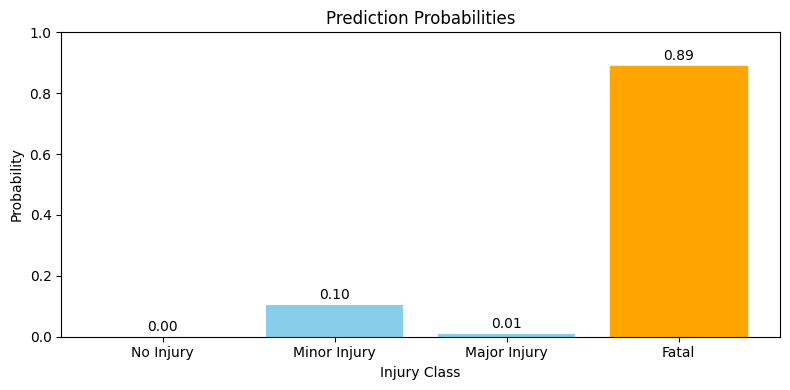

In [27]:
import matplotlib.pyplot as plt

# Probability values from your result
probs = [9.1853364e-14, 1.0290390e-01, 8.5049039e-03, 8.8859123e-01]
class_names = ["No Injury", "Minor Injury", "Major Injury", "Fatal"]

# Plot
plt.figure(figsize=(8, 4))
bars = plt.bar(class_names, probs, color='skyblue')
plt.title("Prediction Probabilities")
plt.xlabel("Injury Class")
plt.ylabel("Probability")
plt.ylim(0, 1)

# Highlight predicted class
pred_index = probs.index(max(probs))
bars[pred_index].set_color('orange')

for i, p in enumerate(probs):
    plt.text(i, p + 0.02, f"{p:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [28]:
import random
import numpy as np
import torch

# Define your categorical and numerical columns
cat_cols = ["Vehicle Type", "Road Surface", "Weather", "Light Condition"]
num_cols = ["Speed", "Age", "Distance", "Reaction Time"]
class_names = ["No Injury", "Minor Injury", "Major Injury", "Fatal"]

# Get unique category sizes (replace with actual if known)
cat_dims = [10, 5, 4, 3]  # Assuming each categorical feature has these many unique values

# Randomly generate a sample
random_cat_vals = [random.randint(0, dim - 1) for dim in cat_dims]
random_num_vals = np.round(np.random.normal(loc=0, scale=1, size=len(num_cols)), 2)

# Convert to tensors
sample_cat = torch.tensor([random_cat_vals], dtype=torch.long).to(device)
sample_num = torch.tensor([random_num_vals], dtype=torch.float32).to(device)

# Predict function
def predict(model, x_cat_tensor, x_num_tensor, class_names, device):
    model.eval()
    x_cat_tensor = x_cat_tensor.to(device)
    x_num_tensor = x_num_tensor.to(device)

    with torch.no_grad():
        output = model(x_cat_tensor, x_num_tensor)
        prob = torch.softmax(output, dim=1)
        pred = torch.argmax(prob, dim=1)
    
    return class_names[pred.item()], prob.squeeze().cpu().numpy()

# Run prediction
pred_class, prob = predict(model, sample_cat, sample_num, class_names, device)

# Display feature-wise input
print("📋 Random Feature Inputs:")
for name, val in zip(cat_cols, random_cat_vals):
    print(f"Categorical - {name}: {val}")
for name, val in zip(num_cols, random_num_vals):
    print(f"Numerical   - {name}: {val:.2f}")

# Display prediction results
print("\n🎯 Classification Result:")
print(f"Predicted Class: {pred_class}")
print("Class Probabilities:")
for i, p in enumerate(prob):
    print(f"  {class_names[i]:<15}: {p:.4f}")


📋 Random Feature Inputs:
Categorical - Vehicle Type: 7
Categorical - Road Surface: 0
Categorical - Weather: 2
Categorical - Light Condition: 1
Numerical   - Speed: 0.37
Numerical   - Age: 0.46
Numerical   - Distance: 1.77
Numerical   - Reaction Time: 0.08

🎯 Classification Result:
Predicted Class: Major Injury
Class Probabilities:
  No Injury      : 0.0000
  Minor Injury   : 0.0234
  Major Injury   : 0.9719
  Fatal          : 0.0047


/tmp/ipykernel_19/3282975281.py:19: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  sample_num = torch.tensor([random_num_vals], dtype=torch.float32).to(device)


Classification Report:

              precision    recall  f1-score   support

   No Injury       0.27      0.00      0.00     13176
Minor Injury       0.83      0.97      0.90   1139637
Major Injury       0.60      0.23      0.33    227316
       Fatal       0.49      0.05      0.09     36214

    accuracy                           0.82   1416343
   macro avg       0.55      0.31      0.33   1416343
weighted avg       0.78      0.82      0.78   1416343



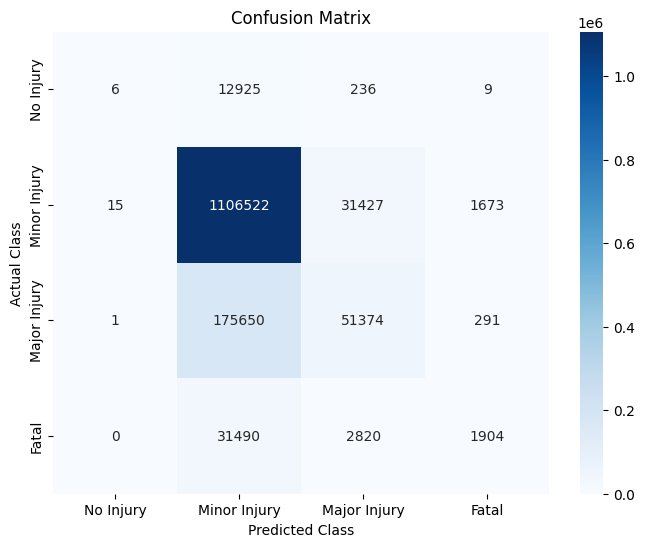

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Convert test data to torch tensors
X_cat_test_tensor = torch.tensor(X_cat_test, dtype=torch.long).to(device)
X_num_test_tensor = torch.tensor(X_num_test, dtype=torch.float32).to(device)

# Step 2: Predict on test data
model.eval()
with torch.no_grad():
    outputs = model(X_cat_test_tensor, X_num_test_tensor)
    probs = torch.softmax(outputs, dim=1)
    y_pred = torch.argmax(probs, dim=1).cpu().numpy()

# Step 3: Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# Step 4: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()

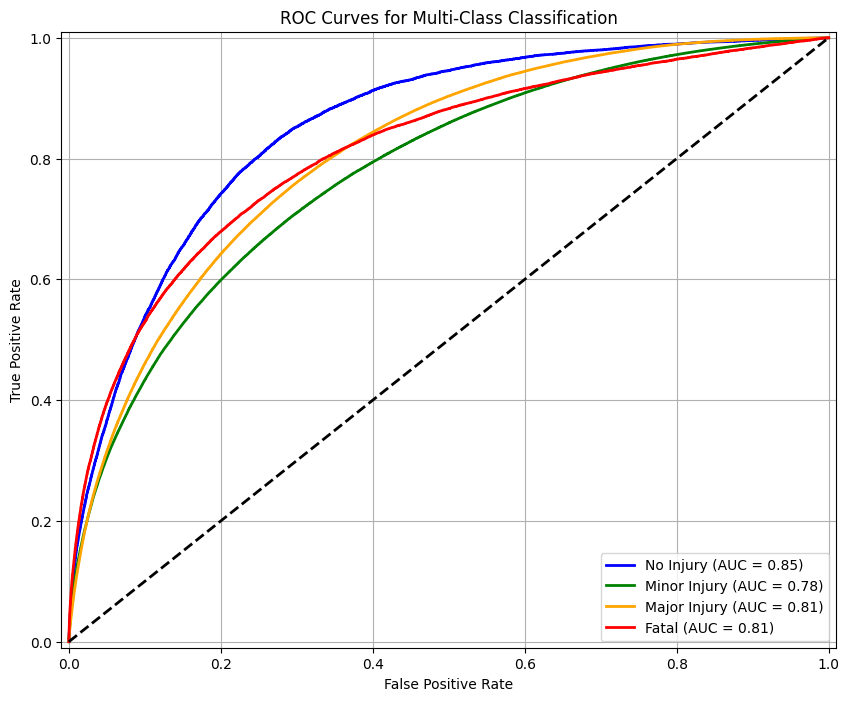

In [30]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert to CPU + NumPy if probs is still a CUDA tensor
probs = probs.detach().cpu().numpy()

# One-hot encode true labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # Adjust if needed

# Compute ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = len(class_names)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'orange', 'red']
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Multi-Class Classification")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
